In [1]:
import os

os.environ["MUJOCO_GL"] = "egl"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

In [2]:
import numpy as np
import mujoco
from vnl_playground.tasks.rodent.run_gap_vision import RunGapVision, default_config

# Print the actual source of _configure_eye_cameras to verify it's the euler fix
import inspect

src = inspect.getsource(RunGapVision._configure_eye_cameras)
print("=== _configure_eye_cameras source ===")
print(src)
print()
print("Uses alt.euler:", "alt.euler" in src)
print("Uses cam.quat:", "cam.quat" in src and "alt.euler" not in src)

=== _configure_eye_cameras source ===
    def _configure_eye_cameras(self, eye_angle_offset: float) -> None:
        """Modify eye camera yaw angles on the spec and recompile.

        Yaws each eye camera outward by ±eye_angle_offset radians around the
        skull's dorsal (Z) axis by modifying the euler Z-component directly.

        The base egocentric euler is [0, -π/2, -π/2] (radians). The third
        component controls yaw in the skull frame:
            left eye:  euler[2] = -π/2 + eye_angle_offset
            right eye: euler[2] = -π/2 - eye_angle_offset

        The resulting binocular overlap (for square images) is approximately:
            overlap_deg ≈ fovy - 2 × degrees(eye_angle_offset)

        Args:
            eye_angle_offset: Yaw offset in radians for each eye from center.
                0.0 = both eyes look straight ahead (max overlap = fovy).
                0.2 ≈ 11.5° offset → ~57° overlap with fovy=80°.
                0.698 ≈ 40° offset → 0° overlap.

   

In [3]:
CONDITIONS = [
    ("Full overlap 80", True, 0.0, 80),
    ("Default 57", True, 0.2, 57),
    ("Rat-like 50", True, 0.262, 50),
    ("Rat-like 40", True, 0.349, 40),
    ("Narrow 20", True, 0.524, 20),
    ("No overlap 0", True, 0.698, 0),
]

print(
    f"{'Condition':<20} {'Left Yaw':>10} {'Right Yaw':>10} {'Inter-gaze':>12} {'Overlap':>10} {'Expected':>10} {'Status':>10}"
)
print("-" * 85)

for label, binocular, offset, expected in CONDITIONS:
    cfg = default_config()
    cfg.mujoco_impl = "warp"
    cfg.binocular = True
    cfg.eye_angle_offset = offset
    env = RunGapVision(config=cfg)
    m = env.mj_model

    lid = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_CAMERA, "eye_left-rodent")
    rid = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_CAMERA, "eye_right-rodent")

    lfwd = -m.cam_mat0[lid].reshape(3, 3)[2]
    rfwd = -m.cam_mat0[rid].reshape(3, 3)[2]

    lyaw = np.degrees(np.arctan2(lfwd[1], lfwd[0]))
    ryaw = np.degrees(np.arctan2(rfwd[1], rfwd[0]))

    ig = np.degrees(np.arccos(np.clip(np.dot(lfwd, rfwd), -1, 1)))
    actual = 80 - ig
    status = "OK" if abs(actual - expected) < 2 else "MISMATCH!"

    print(
        f"{label:<20} {lyaw:>10.1f} {rfwd[0]:>10.1f} {ig:>12.1f} {actual:>10.1f} {expected:>10} {status:>10}"
    )

    # Also print raw cam_mat0 for the 0-overlap case
    if offset == 0.698:
        print(f"\n  Left cam_mat0 forward: {lfwd}")
        print(f"  Left cam_mat0 up:      {m.cam_mat0[lid].reshape(3,3)[1]}")
        print(f"  Right cam_mat0 forward: {rfwd}")
        print(f"  Right cam_mat0 up:      {m.cam_mat0[rid].reshape(3,3)[1]}")

    del env

Condition              Left Yaw  Right Yaw   Inter-gaze    Overlap   Expected     Status
-------------------------------------------------------------------------------------
Warp 1.13.0.dev20260302 initialized:
   Git commit: 2675d53530597430af87c7425a1bbb40a2c5453a
   CUDA Toolkit 12.9, Driver 13.1
   Devices:
     "cpu"      : "CPU"
     "cuda:0"   : "NVIDIA GeForce RTX 5090" (31 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/talmolab/.cache/warp/1.13.0.dev20260302
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.
Full overlap 80           -90.0       -0.0          0.0       80.0         80         OK
Default 57               -101.5        0.2         22.9       57.1         57         OK
Rat-like 50              -105.0        0.3         30.0       50.0         50         OK
Rat-like 40       

Module mujoco.mjx.third_party.mujoco_warp._src.render_util 9cda0d9 load on device 'cuda:0' took 0.33 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.io 4ae9eac load on device 'cuda:0' took 1.56 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.bvh 4527052 load on device 'cuda:0' took 0.43 ms  (cached)
Module mujoco.mjx.warp.ffi 98d2031 load on device 'cuda:0' took 0.21 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.smooth 12773d5 load on device 'cuda:0' took 3.59 ms  (cached)
Module mujoco.mjx.third_party.mujoco_warp._src.collision_driver 4d8b905 load on device 'cuda:0' took 0.24 ms  (cached)
Module _nxn_broadphase__locals__kernel_ea6098d7 ea6098d load on device 'cuda:0' took 0.24 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_ba2335e3 ba2335e load on device 'cuda:0' took 1.03 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_47e99e6d 47e99e6 load on device 'cuda:0' took 1.12 ms  (cached)
Module ccd_kernel_builder__locals__ccd_ker

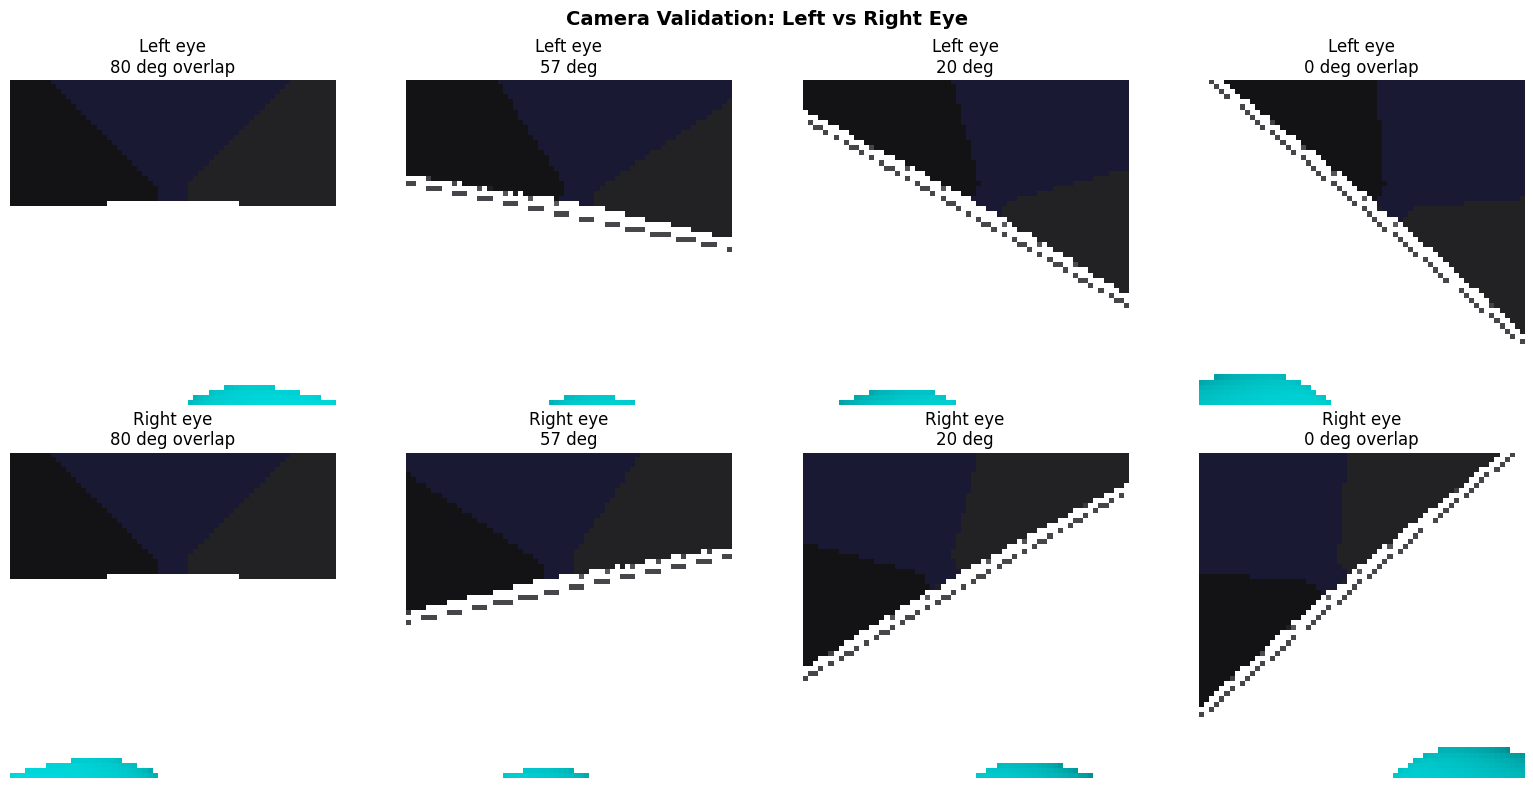

In [4]:
# Render left/right vision for 0-offset and 0.698-offset to visually compare
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from vnl_playground.tasks.rodent.vision_jax import JaxVisionRenderer
from mujoco.mjx.warp.types import DATA_NON_VMAP


def add_batch_dim(data):
    def _maybe_expand(path, x):
        parts = [p.name for p in path if hasattr(p, "name") and p.name != "_impl"]
        attr = "__".join(parts)
        return x if attr in DATA_NON_VMAP else x[None, ...]

    return jax.tree.map_with_path(_maybe_expand, data)


fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, (offset, name) in enumerate(
    [
        (0.0, "80 deg overlap"),
        (0.2, "57 deg"),
        (0.524, "20 deg"),
        (0.698, "0 deg overlap"),
    ]
):
    cfg = default_config()
    cfg.mujoco_impl = "warp"
    cfg.binocular = True
    cfg.eye_angle_offset = offset
    cfg.use_mesh_platforms = True
    cfg.aesthetic = "outdoor_natural"
    env = RunGapVision(config=cfg)

    lr = JaxVisionRenderer(
        mj_model=env.mj_model,
        mjx_model=env.mjx_model,
        nworld=1,
        width=64,
        height=64,
        grayscale=False,
        camera_name="eye_left-rodent",
    )
    rr = JaxVisionRenderer(
        mj_model=env.mj_model,
        mjx_model=env.mjx_model,
        nworld=1,
        width=64,
        height=64,
        grayscale=False,
        camera_name="eye_right-rodent",
    )

    state = jax.jit(env.reset)(jax.random.PRNGKey(42))
    step_fn = jax.jit(env.step)
    for _ in range(30):
        state = step_fn(state, jnp.zeros(env.action_size))

    data_b = add_batch_dim(state.data)
    left_img = np.array(jax.jit(lr.render)(data_b)[0])
    right_img = np.array(jax.jit(rr.render)(data_b)[0])

    axes[0, col].imshow(left_img)
    axes[0, col].set_title(f"Left eye\n{name}")
    axes[0, col].axis("off")
    axes[1, col].imshow(right_img)
    axes[1, col].set_title(f"Right eye\n{name}")
    axes[1, col].axis("off")

    corr = np.corrcoef(left_img.ravel(), right_img.ravel())[0, 1]
    axes[1, col].set_xlabel(f"pixel corr: {corr:.3f}")

    del env, lr, rr

plt.suptitle("Camera Validation: Left vs Right Eye", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()